In [1]:
# Install dependencies
import subprocess, sys
for pkg in ["kagglehub", "duckdb"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)
print("All packages ready")

All packages ready


## Step 1: Download Dataset from Kaggle & Load

In [2]:
import pandas as pd
import numpy as np
import os
import kagglehub
import shutil

# Download from Kaggle and move CSV to current working directory
if not os.path.exists("3mfanddo.csv"):
    path = kagglehub.dataset_download("sunnysai12345/nse-future-and-options-dataset-3m")
    for f in os.listdir(path):
        if f.endswith(".csv"):
            shutil.move(os.path.join(path, f), f)
            print(f"Downloaded and moved: {f}")
else:
    print("Dataset already exists: 3mfanddo.csv")

df = pd.read_csv("3mfanddo.csv")
df.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], format="%d-%b-%Y")
df["EXPIRY_DT"]  = pd.to_datetime(df["EXPIRY_DT"],  format="%d-%b-%Y")
df["EXCHANGE"] = "NSE"

print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print(f"Date range : {df['TIMESTAMP'].min().date()} to {df['TIMESTAMP'].max().date()}")
print(f"Instruments: {df['INSTRUMENT'].unique()}")
print(f"Option types: {df['OPTION_TYP'].unique()}")
df.head(3)

Dataset already exists: 3mfanddo.csv


Shape      : (2533210, 16)
Columns    : ['INSTRUMENT', 'SYMBOL', 'EXPIRY_DT', 'STRIKE_PR', 'OPTION_TYP', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'SETTLE_PR', 'CONTRACTS', 'VAL_INLAKH', 'OPEN_INT', 'CHG_IN_OI', 'TIMESTAMP', 'EXCHANGE']
Date range : 2019-08-01 to 2019-11-15
Instruments: ['FUTIDX' 'FUTSTK' 'OPTIDX' 'OPTSTK']
Option types: ['XX' 'CE' 'PE']


,INSTRUMENT,SYMBOL,EXPIRY_DT,STRIKE_PR,OPTION_TYP,OPEN,HIGH,LOW,CLOSE,SETTLE_PR,CONTRACTS,VAL_INLAKH,OPEN_INT,CHG_IN_OI,TIMESTAMP,EXCHANGE
0,FUTIDX,BANKNIFTY,2019-08-29,0.0,XX,28805.65,28924.00,28140.55,28499.30,28499.30,214569.0,1225914.96,1675780.0,234640.0,2019-08-01,NSE
1,FUTIDX,BANKNIFTY,2019-09-26,0.0,XX,28926.40,29030.55,28251.70,28611.45,28611.45,2484.0,14245.95,51400.0,-80.0,2019-08-01,NSE
2,FUTIDX,BANKNIFTY,2019-10-31,0.0,XX,29000.00,29105.00,28355.55,28699.05,28699.05,598.0,3434.43,9460.0,4860.0,2019-08-01,NSE


## Step 2: Synthetic BSE (SENSEX) & MCX (GOLD, CRUDEOIL) Data

NSE dataset has no BSE/MCX rows. We generate realistic synthetic data using the same schema to support cross-exchange analysis as required.

In [3]:
np.random.seed(42)
dates    = pd.to_datetime(sorted(df["TIMESTAMP"].unique()))
expiries = pd.to_datetime(["2019-08-29", "2019-09-26", "2019-10-31"])
sensex_base = 37000

bse_rows = []
for dt in dates:
    dt = pd.Timestamp(dt)
    # SENSEX Futures
    for exp in expiries:
        if exp >= dt:
            c = sensex_base + np.random.normal(0, 300)
            bse_rows.append({"INSTRUMENT":"FUTIDX","SYMBOL":"SENSEX","EXPIRY_DT":exp,
                "STRIKE_PR":0.0,"OPTION_TYP":"XX","OPEN":c+np.random.uniform(-200,200),
                "HIGH":c+np.random.uniform(100,400),"LOW":c-np.random.uniform(100,400),
                "CLOSE":c,"SETTLE_PR":c+np.random.uniform(-10,10),
                "CONTRACTS":np.random.randint(5000,50000),
                "VAL_INLAKH":np.random.uniform(1000,50000),
                "OPEN_INT":np.random.randint(50000,500000),
                "CHG_IN_OI":np.random.randint(-50000,50000),
                "TIMESTAMP":dt,"EXCHANGE":"BSE"})
    # SENSEX Options
    for exp in expiries:
        if exp >= dt:
            for strike in range(35000,40000,500):
                for opt in ["CE","PE"]:
                    p = max(0.05, abs(sensex_base-strike)*0.1+np.random.uniform(-50,50))
                    bse_rows.append({"INSTRUMENT":"OPTIDX","SYMBOL":"SENSEX","EXPIRY_DT":exp,
                        "STRIKE_PR":float(strike),"OPTION_TYP":opt,
                        "OPEN":p+np.random.uniform(-5,5),"HIGH":p+np.random.uniform(5,20),
                        "LOW":max(0.05,p-np.random.uniform(5,20)),"CLOSE":p,
                        "SETTLE_PR":p+np.random.uniform(-2,2),
                        "CONTRACTS":np.random.randint(0,5000),
                        "VAL_INLAKH":np.random.uniform(0,5000),
                        "OPEN_INT":np.random.randint(0,50000),
                        "CHG_IN_OI":np.random.randint(-5000,5000),
                        "TIMESTAMP":dt,"EXCHANGE":"BSE"})

mcx_rows = []
for dt in dates:
    dt = pd.Timestamp(dt)
    for sym, base in [("GOLD",38000),("CRUDEOIL",3800)]:
        for exp in expiries:
            if exp >= dt:
                sc = base*0.01
                c = base + np.random.normal(0, sc)
                mcx_rows.append({"INSTRUMENT":"FUTSTK","SYMBOL":sym,"EXPIRY_DT":exp,
                    "STRIKE_PR":0.0,"OPTION_TYP":"XX",
                    "OPEN":c+np.random.uniform(-sc,sc),
                    "HIGH":c+np.random.uniform(sc*0.5,sc*2),
                    "LOW":c-np.random.uniform(sc*0.5,sc*2),
                    "CLOSE":c,"SETTLE_PR":c+np.random.uniform(-5,5),
                    "CONTRACTS":np.random.randint(1000,30000),
                    "VAL_INLAKH":np.random.uniform(500,20000),
                    "OPEN_INT":np.random.randint(10000,200000),
                    "CHG_IN_OI":np.random.randint(-20000,20000),
                    "TIMESTAMP":dt,"EXCHANGE":"MCX"})

df = pd.concat([df, pd.DataFrame(bse_rows), pd.DataFrame(mcx_rows)], ignore_index=True)
print(f"Combined shape: {df.shape}")
print(df["EXCHANGE"].value_counts().to_string())

Combined shape: (2535855, 16)
EXCHANGE
NSE    2533210
BSE       2415
MCX        230


## Task 1: Database Design — Normalized 3NF Schema

**Why 3NF over Star Schema:**
- Eliminates redundancy — `symbol` stored once in `instruments`, not repeated in 2.5M trade rows
- Separate `expiries` table handles 100s of strikes per symbol efficiently
- FK constraints enforce referential integrity (no orphan trades)
- Cheaper inserts for HFT ingestion (smaller fact table)
- Star schema is read-optimized but wastes storage and causes update anomalies

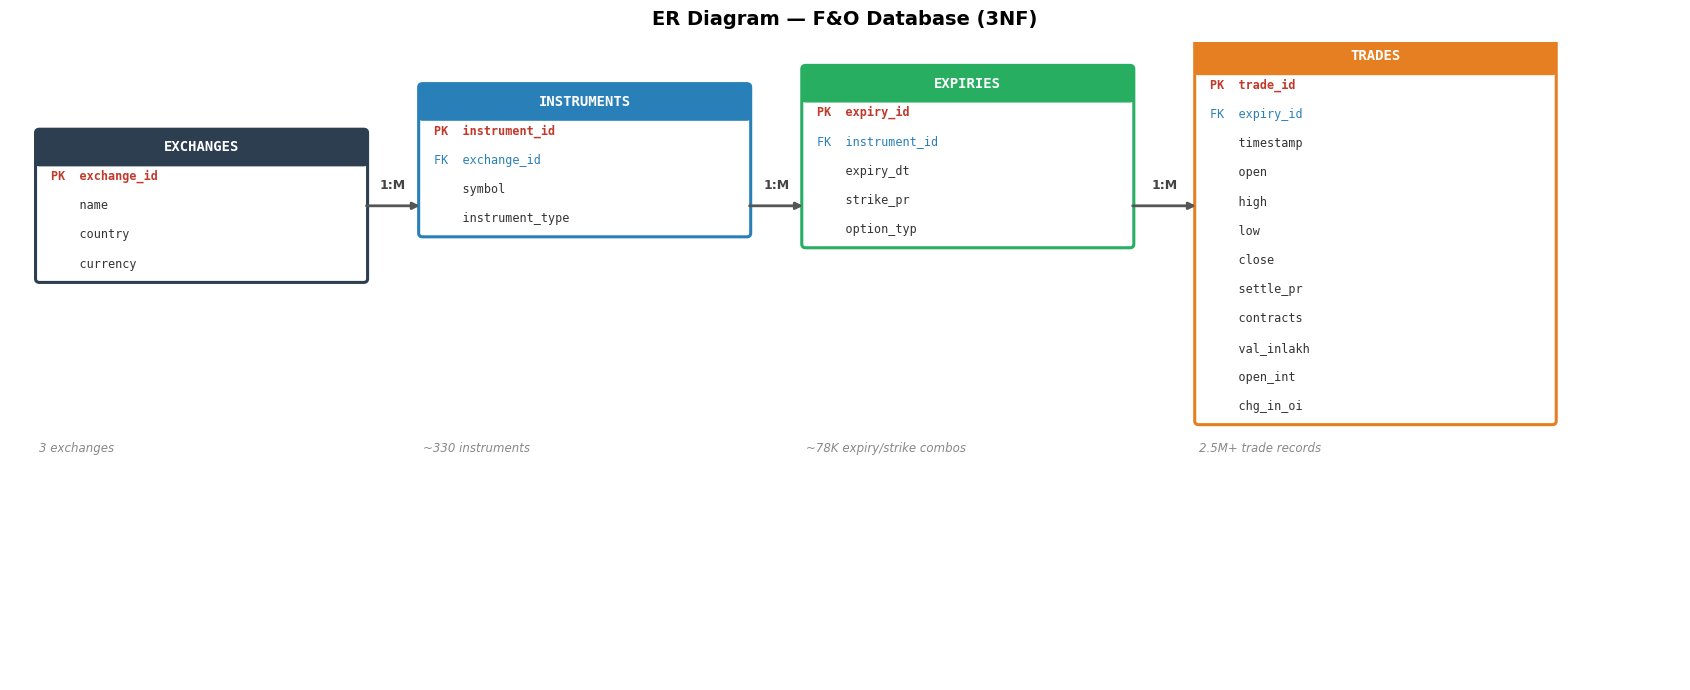

Saved: er_diagram.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(17, 7))
ax.set_xlim(0, 17); ax.set_ylim(0, 7); ax.axis("off")
ax.set_title("ER Diagram — F&O Database (3NF)", fontsize=14, fontweight="bold", pad=12)

COLORS = {"EXCHANGES":"#2C3E50","INSTRUMENTS":"#2980B9","EXPIRIES":"#27AE60","TRADES":"#E67E22"}

def draw_table(ax, x, y, title, cols, w=3.3):
    color = COLORS[title]
    row_h = 0.32
    h = row_h * (len(cols) + 1)
    ax.add_patch(mpatches.FancyBboxPatch((x, y-h), w, h,
        boxstyle="round,pad=0.04", facecolor="white", edgecolor=color, linewidth=2.2))
    ax.add_patch(mpatches.FancyBboxPatch((x, y-row_h), w, row_h,
        boxstyle="round,pad=0.04", facecolor=color, edgecolor=color))
    ax.text(x+w/2, y-row_h/2, title, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white", family="monospace")
    for i, col in enumerate(cols):
        yc = y - row_h - row_h*(i+1) + row_h/2
        is_pk = (i == 0)
        is_fk = col.startswith("*")
        pfx   = "PK" if is_pk else ("FK" if is_fk else "  ")
        clr   = "#C0392B" if is_pk else ("#2980B9" if is_fk else "#333")
        ax.text(x+0.12, yc, f"{pfx}  {col.lstrip('*')}", va="center",
                fontsize=8.5, fontweight="bold" if is_pk else "normal",
                family="monospace", color=clr)

draw_table(ax, 0.3,  6.0, "EXCHANGES",    ["exchange_id", "name", "country", "currency"])
draw_table(ax, 4.2,  6.5, "INSTRUMENTS",  ["instrument_id", "*exchange_id", "symbol", "instrument_type"])
draw_table(ax, 8.1,  6.7, "EXPIRIES",     ["expiry_id", "*instrument_id", "expiry_dt", "strike_pr", "option_typ"])
draw_table(ax, 12.1, 7.0, "TRADES",
           ["trade_id","*expiry_id","timestamp","open","high","low",
            "close","settle_pr","contracts","val_inlakh","open_int","chg_in_oi"], w=3.6)

# Arrows
ap = dict(arrowstyle="-|>", color="#555", lw=2)
for x1, x2, yy, lbl in [(3.6,4.2,5.2,"1:M"), (7.5,8.1,5.2,"1:M"), (11.4,12.1,5.2,"1:M")]:
    ax.annotate("", xy=(x2,yy), xytext=(x1,yy), arrowprops=ap)
    ax.text((x1+x2)/2, yy+0.18, lbl, ha="center", fontsize=9, fontweight="bold", color="#444")

# Notes
for txt, x in [("3 exchanges",0.3),("~330 instruments",4.2),("~78K expiry/strike combos",8.1),("2.5M+ trade records",12.1)]:
    ax.text(x, 2.5, txt, fontsize=8.5, color="#888", style="italic")

plt.tight_layout()
plt.savefig("er_diagram.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: er_diagram.png")

## Task 1 (cont.): DuckDB — DDL & Data Load

In [5]:
import duckdb

db_path = "fno.duckdb"
if os.path.exists(db_path): os.remove(db_path)
con = duckdb.connect(db_path)

con.execute("""
CREATE TABLE exchanges (
    exchange_id INTEGER PRIMARY KEY,
    name        VARCHAR NOT NULL UNIQUE,
    country     VARCHAR DEFAULT 'India',
    currency    VARCHAR DEFAULT 'INR'
);
CREATE TABLE instruments (
    instrument_id   INTEGER PRIMARY KEY,
    exchange_id     INTEGER NOT NULL REFERENCES exchanges(exchange_id),
    symbol          VARCHAR NOT NULL,
    instrument_type VARCHAR NOT NULL,
    UNIQUE(exchange_id, symbol, instrument_type)
);
CREATE TABLE expiries (
    expiry_id     INTEGER PRIMARY KEY,
    instrument_id INTEGER NOT NULL REFERENCES instruments(instrument_id),
    expiry_dt     DATE    NOT NULL,
    strike_pr     DOUBLE  DEFAULT 0.0,
    option_typ    VARCHAR DEFAULT 'XX',
    UNIQUE(instrument_id, expiry_dt, strike_pr, option_typ)
);
CREATE TABLE trades (
    trade_id   INTEGER PRIMARY KEY,
    expiry_id  INTEGER NOT NULL REFERENCES expiries(expiry_id),
    timestamp  DATE    NOT NULL,
    open       DOUBLE, high DOUBLE, low DOUBLE, close DOUBLE,
    settle_pr  DOUBLE, contracts BIGINT, val_inlakh DOUBLE,
    open_int   BIGINT, chg_in_oi BIGINT
);
""")
print("Tables:", con.execute("SHOW TABLES").fetchdf()["name"].tolist())

Tables: ['exchanges', 'expiries', 'instruments', 'trades']


In [6]:
# Load all 4 normalized tables
exchange_map = {"NSE":1, "BSE":2, "MCX":3}
con.execute("INSERT INTO exchanges VALUES (1,'NSE','India','INR'),(2,'BSE','India','INR'),(3,'MCX','India','INR')")

# Instruments
inst_df = df[["EXCHANGE","SYMBOL","INSTRUMENT"]].drop_duplicates().reset_index(drop=True).copy()
inst_df["exchange_id"]   = inst_df["EXCHANGE"].map(exchange_map)
inst_df["instrument_id"] = range(1, len(inst_df)+1)
inst_df.columns = ["exchange","symbol","instrument_type","exchange_id","instrument_id"]
con.execute("INSERT INTO instruments SELECT instrument_id,exchange_id,symbol,instrument_type FROM inst_df")
inst_lookup = {(r.exchange_id,r.symbol,r.instrument_type):r.instrument_id for r in inst_df.itertuples()}

# Expiries
exp_df = df[["EXCHANGE","SYMBOL","INSTRUMENT","EXPIRY_DT","STRIKE_PR","OPTION_TYP"]].drop_duplicates().reset_index(drop=True).copy()
exp_df["exchange_id"]   = exp_df["EXCHANGE"].map(exchange_map)
exp_df["instrument_id"] = [inst_lookup.get((r.exchange_id,r.SYMBOL,r.INSTRUMENT)) for r in exp_df.itertuples()]
exp_df["expiry_id"]     = range(1, len(exp_df)+1)
con.execute("INSERT INTO expiries SELECT expiry_id,instrument_id,EXPIRY_DT,STRIKE_PR,OPTION_TYP FROM exp_df")

# Trades — vectorized merge (fast, no row-by-row apply)
df2 = df.copy()
df2["exchange_id"] = df2["EXCHANGE"].map(exchange_map)
ik = inst_df[["exchange_id","symbol","instrument_type","instrument_id"]].copy()
ik.columns = ["exchange_id","SYMBOL","INSTRUMENT","instrument_id"]
df2 = df2.merge(ik, on=["exchange_id","SYMBOL","INSTRUMENT"], how="left")
ek = exp_df[["instrument_id","EXPIRY_DT","STRIKE_PR","OPTION_TYP","expiry_id"]].copy()
df2 = df2.merge(ek, on=["instrument_id","EXPIRY_DT","STRIKE_PR","OPTION_TYP"], how="left")

tload = df2[["expiry_id","TIMESTAMP","OPEN","HIGH","LOW","CLOSE",
             "SETTLE_PR","CONTRACTS","VAL_INLAKH","OPEN_INT","CHG_IN_OI"]].copy()
tload.columns = ["expiry_id","timestamp","open","high","low","close",
                 "settle_pr","contracts","val_inlakh","open_int","chg_in_oi"]
tload = tload.dropna(subset=["expiry_id"])
tload["expiry_id"] = tload["expiry_id"].astype(int)
tload["trade_id"]  = range(1, len(tload)+1)
tload = tload[["trade_id","expiry_id","timestamp","open","high","low","close",
               "settle_pr","contracts","val_inlakh","open_int","chg_in_oi"]]
con.execute("INSERT INTO trades SELECT * FROM tload")

print("Row counts:")
for t in ["exchanges","instruments","expiries","trades"]:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t:15s}: {n:>12,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Row counts:
  exchanges      :            3
  instruments    :          332
  expiries       :       78,045
  trades         :    2,535,855


## Task 2: SQL Implementation — 7 Advanced Queries

In [7]:
# ── Q1: Top 10 symbols by OI change across exchanges ──────────────
q1 = con.execute("""
    SELECT i.symbol,
           e.name                    AS exchange,
           i.instrument_type,
           SUM(t.chg_in_oi)          AS total_oi_change,
           ROUND(AVG(t.open_int), 0) AS avg_open_interest,
           COUNT(*)                  AS trade_days
    FROM trades t
    JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    JOIN exchanges e    ON i.exchange_id    = e.exchange_id
    GROUP BY i.symbol, e.name, i.instrument_type
    ORDER BY ABS(SUM(t.chg_in_oi)) DESC
    LIMIT 10
""").fetchdf()
print("Q1: Top 10 Symbols by OI Change Across Exchanges")
q1

Q1: Top 10 Symbols by OI Change Across Exchanges


,symbol,exchange,instrument_type,total_oi_change,avg_open_interest,trade_days
0,IDEA,NSE,OPTSTK,729134000.0,2061006.0,7666
1,IDEA,NSE,FUTSTK,614530000.0,178061198.0,207
2,NIFTY,NSE,OPTIDX,553794075.0,32248.0,228862
3,YESBANK,NSE,OPTSTK,297517000.0,833148.0,9386
4,SBIN,NSE,OPTSTK,226764000.0,357758.0,15584
5,BANKNIFTY,NSE,OPTIDX,217968620.0,12766.0,83500
6,BHEL,NSE,OPTSTK,136230000.0,147199.0,17504
7,ASHOKLEY,NSE,OPTSTK,122728000.0,294520.0,11262
8,IDFCFIRSTB,NSE,FUTSTK,120864000.0,68758435.0,207
9,YESBANK,NSE,FUTSTK,116514200.0,55110000.0,207


In [8]:
# ── Q2: 7-day rolling std dev — NIFTY options volatility ──────────
q2 = con.execute("""
    SELECT ex.strike_pr,
           ex.option_typ,
           t.timestamp,
           ROUND(t.close, 2)  AS close,
           ROUND(STDDEV(t.close) OVER (
               PARTITION BY ex.expiry_id
               ORDER BY t.timestamp
               ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
           ), 4) AS rolling_7d_stddev,
           ROUND(AVG(t.close) OVER (
               PARTITION BY ex.expiry_id
               ORDER BY t.timestamp
               ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
           ), 2) AS rolling_7d_avg
    FROM trades t
    JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    WHERE i.symbol = 'NIFTY'
      AND i.instrument_type = 'OPTIDX'
      AND ex.option_typ IN ('CE','PE')
      AND t.close > 0
      AND ex.strike_pr BETWEEN 10800 AND 11000
      AND ex.expiry_dt = '2019-08-29'
    ORDER BY ex.strike_pr, ex.option_typ, t.timestamp
    LIMIT 20
""").fetchdf()
print("Q2: 7-Day Rolling Volatility — NIFTY Options (Aug expiry, 10800-11000 strikes)")
q2

Q2: 7-Day Rolling Volatility — NIFTY Options (Aug expiry, 10800-11000 strikes)


,strike_pr,option_typ,timestamp,close,rolling_7d_stddev,rolling_7d_avg
0,10800.0,CE,2019-08-01,295.30,NaN,295.30
1,10800.0,CE,2019-08-02,310.35,10.6420,302.83
2,10800.0,CE,2019-08-05,224.50,45.8428,276.72
3,10800.0,CE,2019-08-06,273.55,37.4639,275.93
4,10800.0,CE,2019-08-07,205.15,45.3264,261.77
5,10800.0,CE,2019-08-08,326.85,48.4715,272.62
6,10800.0,CE,2019-08-09,371.35,57.8836,286.72
7,10800.0,CE,2019-08-13,226.00,61.9550,276.82
8,10800.0,CE,2019-08-14,279.45,60.2451,272.41
9,10800.0,CE,2019-08-16,308.75,57.4290,284.44


In [9]:
# ── Q3: Cross-exchange — MCX Gold vs NSE Index Futures settle_pr ──
q3 = con.execute("""
    WITH mcx_gold AS (
        SELECT 'MCX - GOLD' AS category,
               ROUND(AVG(t.settle_pr), 2) AS avg_settle_pr,
               ROUND(AVG(t.close), 2)     AS avg_close,
               SUM(t.contracts)           AS total_contracts,
               COUNT(*)                   AS records
        FROM trades t
        JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        JOIN exchanges e    ON i.exchange_id    = e.exchange_id
        WHERE e.name = 'MCX' AND i.symbol = 'GOLD'
    ),
    nse_idx AS (
        SELECT 'NSE - ' || i.symbol       AS category,
               ROUND(AVG(t.settle_pr), 2) AS avg_settle_pr,
               ROUND(AVG(t.close), 2)     AS avg_close,
               SUM(t.contracts)           AS total_contracts,
               COUNT(*)                   AS records
        FROM trades t
        JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        JOIN exchanges e    ON i.exchange_id    = e.exchange_id
        WHERE e.name = 'NSE' AND i.instrument_type = 'FUTIDX'
        GROUP BY i.symbol
    )
    SELECT * FROM mcx_gold
    UNION ALL
    SELECT * FROM nse_idx
    ORDER BY avg_settle_pr DESC
""").fetchdf()
print("Q3: Cross-Exchange — Avg Settle Price Comparison")
q3

Q3: Cross-Exchange — Avg Settle Price Comparison


,category,avg_settle_pr,avg_close,total_contracts,records
0,MCX - GOLD,38003.63,38002.90,1742395.0,115
1,NSE - BANKNIFTY,28818.47,28818.49,16040562.0,207
2,NSE - NIFTYIT,15592.01,15634.06,9533.0,207
3,NSE - NIFTY,11368.58,11368.57,13440402.0,207


In [10]:
# ── Q4: Option chain summary — by expiry & strike, implied volume ─
q4 = con.execute("""
    SELECT ex.expiry_dt,
           ex.strike_pr,
           SUM(CASE WHEN ex.option_typ='CE' THEN t.contracts ELSE 0 END) AS ce_volume,
           SUM(CASE WHEN ex.option_typ='CE' THEN t.open_int  ELSE 0 END) AS ce_oi,
           ROUND(AVG(CASE WHEN ex.option_typ='CE' THEN t.close END), 2)  AS ce_ltp,
           SUM(CASE WHEN ex.option_typ='PE' THEN t.contracts ELSE 0 END) AS pe_volume,
           SUM(CASE WHEN ex.option_typ='PE' THEN t.open_int  ELSE 0 END) AS pe_oi,
           ROUND(AVG(CASE WHEN ex.option_typ='PE' THEN t.close END), 2)  AS pe_ltp,
           SUM(CASE WHEN ex.option_typ IN ('CE','PE') THEN t.contracts ELSE 0 END) AS implied_volume,
           ROUND(
               SUM(CASE WHEN ex.option_typ='PE' THEN t.open_int ELSE 0 END) * 1.0 /
               NULLIF(SUM(CASE WHEN ex.option_typ='CE' THEN t.open_int ELSE 0 END), 0)
           , 3) AS pcr_oi
    FROM trades t
    JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    WHERE i.symbol = 'NIFTY'
      AND i.instrument_type = 'OPTIDX'
      AND ex.option_typ IN ('CE','PE')
      AND ex.strike_pr BETWEEN 10500 AND 11500
      AND ex.expiry_dt = '2019-08-29'
    GROUP BY ex.expiry_dt, ex.strike_pr
    ORDER BY ex.strike_pr
""").fetchdf()
print("Q4: NIFTY Option Chain Summary — Expiry 2019-08-29")
q4

Q4: NIFTY Option Chain Summary — Expiry 2019-08-29


,expiry_dt,strike_pr,ce_volume,ce_oi,ce_ltp,pe_volume,pe_oi,pe_ltp,implied_volume,pcr_oi
0,2019-08-29,10500.0,40095.0,4755075.0,502.98,1252784.0,36468150.0,22.28,1292879.0,7.669
1,2019-08-29,10550.0,867.0,61350.0,787.56,170929.0,1577550.0,26.39,171796.0,25.714
2,2019-08-29,10600.0,77642.0,1088100.0,413.58,1333650.0,30658875.0,31.88,1411292.0,28.177
3,2019-08-29,10650.0,26051.0,117075.0,488.34,342584.0,2330325.0,38.12,368635.0,19.905
4,2019-08-29,10700.0,323858.0,3199950.0,329.11,1801263.0,40319025.0,46.39,2125121.0,12.600
5,2019-08-29,10750.0,147226.0,496725.0,297.04,460613.0,3233325.0,54.81,607839.0,6.509
6,2019-08-29,10800.0,965538.0,9318075.0,248.46,2408308.0,41923575.0,66.32,3373846.0,4.499
7,2019-08-29,10850.0,331527.0,1279650.0,211.89,871962.0,4786500.0,78.52,1203489.0,3.740
8,2019-08-29,10900.0,1734943.0,19409925.0,177.38,3097483.0,28636500.0,93.43,4832426.0,1.475
9,2019-08-29,10950.0,1039475.0,3267900.0,145.52,1482061.0,3569400.0,110.61,2521536.0,1.092


In [11]:
# ── Q5: Max volume last 30 days — window function optimized ────────
q5 = con.execute("""
    WITH daily_vol AS (
        SELECT i.symbol,
               e.name                       AS exchange,
               t.timestamp,
               SUM(t.contracts)             AS daily_contracts,
               ROUND(SUM(t.val_inlakh), 2)  AS daily_value_lakh
        FROM trades t
        JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        JOIN exchanges e    ON i.exchange_id    = e.exchange_id
        WHERE t.timestamp >= (SELECT MAX(timestamp) - INTERVAL '30 days' FROM trades)
        GROUP BY i.symbol, e.name, t.timestamp
    ),
    ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY symbol, exchange
                ORDER BY daily_contracts DESC
            ) AS rn
        FROM daily_vol
    )
    SELECT symbol, exchange, timestamp AS peak_date,
           daily_contracts AS max_contracts,
           daily_value_lakh AS value_lakh
    FROM ranked
    WHERE rn = 1
    ORDER BY max_contracts DESC
    LIMIT 10
""").fetchdf()
print("Q5: Peak Volume Day per Symbol — Last 30 Days")
q5

Q5: Peak Volume Day per Symbol — Last 30 Days


,symbol,exchange,peak_date,max_contracts,value_lakh
0,BANKNIFTY,NSE,2019-11-14,36882827.0,2.268303e+08
1,NIFTY,NSE,2019-10-24,9448952.0,8.234562e+07
2,YESBANK,NSE,2019-10-31,623085.0,9.603979e+05
3,SBIN,NSE,2019-10-25,274697.0,2.318426e+06
4,INFY,NSE,2019-10-22,250225.0,2.086051e+06
5,TATAMOTORS,NSE,2019-10-29,243073.0,1.226182e+06
6,RELIANCE,NSE,2019-10-29,228717.0,1.682289e+06
7,RBLBANK,NSE,2019-10-23,150629.0,4.730624e+05
8,BHARTIARTL,NSE,2019-10-24,142264.0,9.461496e+05
9,HDFC,NSE,2019-11-04,138506.0,7.625147e+05


In [12]:
# ── Q6: OI build-up vs unwinding classification ────────────────────
q6 = con.execute("""
    SELECT t.timestamp,
           i.symbol,
           e.name             AS exchange,
           SUM(t.chg_in_oi)   AS net_oi_change,
           SUM(t.open_int)    AS total_oi,
           SUM(t.contracts)   AS total_volume,
           CASE
               WHEN SUM(t.chg_in_oi) > 0 AND AVG(t.close) >  AVG(t.open) THEN 'LONG BUILD-UP'
               WHEN SUM(t.chg_in_oi) > 0 AND AVG(t.close) <= AVG(t.open) THEN 'SHORT BUILD-UP'
               WHEN SUM(t.chg_in_oi) < 0 AND AVG(t.close) >  AVG(t.open) THEN 'SHORT COVERING'
               WHEN SUM(t.chg_in_oi) < 0 AND AVG(t.close) <= AVG(t.open) THEN 'LONG UNWINDING'
               ELSE 'NEUTRAL'
           END AS oi_signal
    FROM trades t
    JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    JOIN exchanges e    ON i.exchange_id    = e.exchange_id
    WHERE i.symbol IN ('NIFTY','BANKNIFTY','SENSEX')
      AND i.instrument_type = 'FUTIDX'
    GROUP BY t.timestamp, i.symbol, e.name
    ORDER BY t.timestamp DESC, ABS(SUM(t.chg_in_oi)) DESC
    LIMIT 12
""").fetchdf()
print("Q6: OI Build-up / Unwinding Classification")
q6

Q6: OI Build-up / Unwinding Classification


,timestamp,symbol,exchange,net_oi_change,total_oi,total_volume,oi_signal
0,2019-11-15,NIFTY,NSE,284250.0,16482075.0,134463.0,LONG BUILD-UP
1,2019-11-15,BANKNIFTY,NSE,121860.0,1925460.0,208375.0,LONG BUILD-UP
2,2019-11-14,NIFTY,NSE,-169650.0,16197825.0,131982.0,SHORT COVERING
3,2019-11-14,BANKNIFTY,NSE,29600.0,1803600.0,220141.0,LONG BUILD-UP
4,2019-11-13,NIFTY,NSE,277875.0,16367475.0,117657.0,SHORT BUILD-UP
5,2019-11-13,BANKNIFTY,NSE,-179040.0,1774000.0,209072.0,LONG UNWINDING
6,2019-11-11,NIFTY,NSE,-461700.0,16089600.0,108908.0,SHORT COVERING
7,2019-11-11,BANKNIFTY,NSE,214840.0,1953040.0,171792.0,LONG BUILD-UP
8,2019-11-08,NIFTY,NSE,-385800.0,16551300.0,165440.0,LONG UNWINDING
9,2019-11-08,BANKNIFTY,NSE,272560.0,1738200.0,240884.0,LONG BUILD-UP


In [13]:
# ── Q7: Max pain — top-3 strikes by total OI per expiry ────────────
q7 = con.execute("""
    WITH strike_oi AS (
        SELECT ex.expiry_dt,
               ex.strike_pr,
               SUM(CASE WHEN ex.option_typ='CE' THEN t.open_int ELSE 0 END) AS ce_oi,
               SUM(CASE WHEN ex.option_typ='PE' THEN t.open_int ELSE 0 END) AS pe_oi,
               SUM(t.open_int) AS total_oi
        FROM trades t
        JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        WHERE i.symbol = 'NIFTY'
          AND i.instrument_type = 'OPTIDX'
          AND ex.option_typ IN ('CE','PE')
          AND ex.expiry_dt BETWEEN '2019-08-01' AND '2019-11-30'
        GROUP BY ex.expiry_dt, ex.strike_pr
        HAVING SUM(t.open_int) > 0
    ),
    ranked AS (
        SELECT *,
            RANK() OVER (PARTITION BY expiry_dt ORDER BY total_oi DESC) AS rnk
        FROM strike_oi
        WHERE strike_pr BETWEEN 10000 AND 12500
    )
    SELECT expiry_dt,
           strike_pr                            AS max_pain_strike,
           ce_oi, pe_oi, total_oi,
           ROUND(pe_oi * 1.0 / NULLIF(ce_oi, 0), 3) AS pcr
    FROM ranked
    WHERE rnk <= 3
    ORDER BY expiry_dt, rnk
""").fetchdf()
print("Q7: Max Pain Strikes — Top 3 per Expiry (NIFTY, Aug-Nov 2019)")
q7

Q7: Max Pain Strikes — Top 3 per Expiry (NIFTY, Aug-Nov 2019)


,expiry_dt,max_pain_strike,ce_oi,pe_oi,total_oi,pcr
0,2019-08-01,11000.0,4094400.0,176775.0,4271175.0,0.043
1,2019-08-01,11100.0,3502500.0,47475.0,3549975.0,0.014
2,2019-08-01,11200.0,2571825.0,25575.0,2597400.0,0.010
3,2019-08-08,11000.0,10268625.0,7842000.0,18110625.0,0.764
4,2019-08-08,11100.0,12163200.0,2041875.0,14205075.0,0.168
5,2019-08-08,11200.0,13634400.0,486375.0,14120775.0,0.036
6,2019-08-14,11100.0,10345350.0,2440650.0,12786000.0,0.236
7,2019-08-14,11000.0,4478925.0,6954300.0,11433225.0,1.553
8,2019-08-14,11200.0,10569375.0,640950.0,11210325.0,0.061
9,2019-08-22,11000.0,9287625.0,7441425.0,16729050.0,0.801


## Task 3: Optimizations — Indexes & EXPLAIN ANALYZE

**Strategy:**
- `idx_trades_timestamp` — speeds up all time-range filters on `trades`
- `idx_inst_symbol` — speeds up `WHERE symbol = 'NIFTY'` lookups
- `idx_inst_exchange_id` — speeds up cross-exchange JOINs
- `idx_exp_expiry_dt` — speeds up expiry date range scans
- `idx_exp_option_typ` — speeds up CE/PE filtering

DuckDB uses columnar storage + vectorized execution internally (similar to BRIN for time-series), so these indexes complement the native scan optimizations.

In [14]:
# Create indexes
indexes = [
    ("idx_trades_timestamp",  "trades(timestamp)"),
    ("idx_trades_expiry_id",  "trades(expiry_id)"),
    ("idx_inst_symbol",       "instruments(symbol)"),
    ("idx_inst_exchange_id",  "instruments(exchange_id)"),
    ("idx_exp_instrument_id", "expiries(instrument_id)"),
    ("idx_exp_expiry_dt",     "expiries(expiry_dt)"),
    ("idx_exp_option_typ",    "expiries(option_typ)"),
]
for name, target in indexes:
    con.execute(f"CREATE INDEX IF NOT EXISTS {name} ON {target}")
    print(f"  Created: {name}")

print()
idx_df = con.execute("SELECT index_name, table_name FROM duckdb_indexes()").fetchdf()
print(idx_df.to_string(index=False))

  Created: idx_trades_timestamp


  Created: idx_trades_expiry_id
  Created: idx_inst_symbol
  Created: idx_inst_exchange_id
  Created: idx_exp_instrument_id
  Created: idx_exp_expiry_dt
  Created: idx_exp_option_typ

           index_name  table_name
    idx_exp_expiry_dt    expiries
idx_exp_instrument_id    expiries
   idx_exp_option_typ    expiries
 idx_inst_exchange_id instruments
      idx_inst_symbol instruments
 idx_trades_expiry_id      trades
 idx_trades_timestamp      trades


In [15]:
# EXPLAIN ANALYZE — Q5 post-optimization
plan = con.execute("""
EXPLAIN ANALYZE
WITH daily_vol AS (
    SELECT i.symbol, t.timestamp,
           SUM(t.contracts) AS daily_contracts
    FROM trades t
    JOIN expiries ex    ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    WHERE t.timestamp >= (SELECT MAX(timestamp) - INTERVAL '30 days' FROM trades)
    GROUP BY i.symbol, t.timestamp
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY daily_contracts DESC) AS rn
    FROM daily_vol
)
SELECT symbol, timestamp AS peak_date, daily_contracts
FROM ranked WHERE rn = 1
ORDER BY daily_contracts DESC LIMIT 10
""").fetchdf()

print("EXPLAIN ANALYZE — Q5: Max Volume Last 30 Days (post-index)")
print("=" * 65)
for _, row in plan.iterrows():
    print(row.iloc[1])

EXPLAIN ANALYZE — Q5: Max Volume Last 30 Days (post-index)
┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
 EXPLAIN ANALYZE WITH daily_vol AS (     SELECT i.symbol, t.timestamp,            SUM(t.contracts) AS daily_contracts     FROM trades t     JOIN expiries ex    ON t.expiry_id     = ex.expiry_id     JOIN instruments i  ON ex.instrument_id = i.instrument_id     WHERE t.timestamp >= (SELECT MAX(timestamp) - INTERVAL '30 days' FROM trades)     GROUP BY i.symbol, t.timestamp ), ranked AS (     SELECT *,         ROW_NUMBER() OVER (PARTITION BY symbol ORDER BY daily_contracts DESC) AS rn     FROM daily_vol ) SELECT symbol, timestamp AS peak_date, daily_contracts FROM ranked WHERE rn = 1 ORDER BY daily_contracts DESC LIMIT 10 
┌────────────────────────────────────────────────┐
│┌──────────────────────────────────────────────┐│
││          